# Random Forest con validacion LOSO (etiquetas individuales)

Este notebook implementa el **Experimento A** con `RandomForestClassifier`: features derivadas de HR/R-R, ECG y variables temporales.

Cada trabajador obtiene sus propios umbrales P33/P66 calculados sobre todo su registro `FatigueIndex`. LOSO evalua la generalizacion a trabajadores no vistos usando esas etiquetas relativas.

## Etiquetado individual

1. Para cada trabajador se calculan P33 y P66 usando todo su `FatigueIndex` valido.
2. Se crean `Low`, `Medium` y `High` en `FatigueLevel` con esos umbrales propios.
3. LOSO usa directamente `FatigueLevel` en TRAIN y TEST.
4. Los imputadores se ajustan solo con TRAIN.

Las entradas son las columnas `_z`, normalizadas respecto a la baseline individual. `FatigueIndex` no se usa como feature.

In [1]:
from pathlib import Path

import json
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

current_dir = Path.cwd()
candidate_roots = [
    current_dir,
    current_dir.parent,
    current_dir.parent.parent,
    current_dir.parent.parent.parent,
    current_dir / 'new',
]
ROOT_DIR = next(
    (
        candidate
        for candidate in candidate_roots
        if (candidate / 'W00' / 'PROCESSED' / 'combined_features_1min.csv').exists()
    ),
    current_dir,
)
DATA_DIR = ROOT_DIR
BASELINE_WINDOW_COUNT = 15
TARGET_COLUMN_CANDIDATES = ['FatigueIndex', 'fatigue_index']
LABELS = ['Low', 'Medium', 'High']
RF_PARAM_GRID = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_leaf': [1, 2, 4],
}

print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new


## Carga de datos

Cada CSV corresponde a un trabajador. El nombre de la carpeta (`W00`, ..., `W08`) se conserva como identificador para construir los folds, pero nunca entra como feature del modelo.

In [2]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(
        fatigue_values,
        bins=[-np.inf, p33, p66, np.inf],
        labels=LABELS,
        right=False,
    ).astype(object)


worker_files = {
    worker_dir.name: worker_dir / 'PROCESSED' / 'combined_features_1min.csv'
    for worker_dir in sorted(DATA_DIR.glob('W[0-9][0-9]'))
    if (worker_dir / 'PROCESSED' / 'combined_features_1min.csv').exists()
}
if len(worker_files) < 2:
    raise ValueError(f'Se necesitan al menos 2 trabajadores procesados y se encontraron {len(worker_files)}: {list(worker_files)}')

data = {}
for worker, path in worker_files.items():
    frame = pd.read_csv(path)
    target_matches = [column for column in TARGET_COLUMN_CANDIDATES if column in frame.columns]
    if len(target_matches) != 1:
        raise ValueError(f'{worker}: no se encontro exactamente una columna FatigueIndex/fatigue_index')
    frame = frame.rename(columns={target_matches[0]: 'FatigueIndex'})
    worker_fatigue = pd.to_numeric(frame['FatigueIndex'], errors='coerce')
    valid_fatigue = worker_fatigue.dropna()
    if valid_fatigue.empty:
        raise ValueError(f'{worker}: no contiene valores validos de FatigueIndex')
    worker_p33, worker_p66 = np.percentile(valid_fatigue, [33, 66])
    frame['P33_worker'] = worker_p33
    frame['P66_worker'] = worker_p66
    frame['FatigueLevel'] = make_labels(worker_fatigue, worker_p33, worker_p66)
    frame['Trabajador'] = worker
    data[worker] = frame

feature_columns = [
    'ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z',
    'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z',
    'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z',
]
missing_features = [column for column in feature_columns if column not in data[next(iter(data))].columns]
if missing_features:
    raise ValueError(f'Faltan features requeridas: {missing_features}')
if not feature_columns:
    raise ValueError('No se encontraron columnas de entrada terminadas en _z')

print('Trabajadores:', list(data))
print('Features del Experimento A:', feature_columns)
print('Ventanas:', {worker: len(frame) for worker, frame in data.items()})

Trabajadores: ['W00', 'W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09']
Features del Experimento A: ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z', 'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
Ventanas: {'W00': 104, 'W01': 637, 'W02': 603, 'W03': 407, 'W04': 562, 'W05': 74, 'W06': 35, 'W07': 67, 'W08': 133, 'W09': 16}


## Funciones de target y evaluacion

Los percentiles se calculan en cada fold y solo con el vector de `FatigueIndex` de TRAIN. Los valores faltantes del target no se usan para calcular percentiles ni para entrenar/evaluar ese fold.

In [3]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(fatigue_values, bins=[-np.inf, p33, p66, np.inf], labels=LABELS, right=False).astype(object)


def build_model(n_estimators=200, max_depth=None, min_samples_leaf=1):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            class_weight='balanced', n_jobs=-1, random_state=42,
        )),
    ])


def encode_labels(labels):
    label_codes = pd.Categorical(labels, categories=LABELS).codes
    if (label_codes < 0).any():
        raise ValueError('Se encontro una etiqueta fuera de LABELS')
    return label_codes


def decode_labels(label_codes):
    return np.asarray(LABELS, dtype=object)[np.asarray(label_codes, dtype=int)]


def optimize_model(X_train, y_train):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(
        estimator=build_model(), param_grid=RF_PARAM_GRID,
        scoring='balanced_accuracy', cv=inner_cv, refit=True, n_jobs=-1,
    )
    search.fit(X_train, encode_labels(y_train))
    return search

## Experimento A

Features utilizadas: todas las columnas `_z` disponibles, que corresponden a features derivadas de HR/R-R y ECG.

La matriz de confusion utiliza siempre el orden `Low`, `Medium`, `High`.

In [4]:
fold_results = []
confusion_matrices = {}

for test_worker in sorted(data):
    train_workers = [worker for worker in sorted(data) if worker != test_worker]
    train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
    test_frame = data[test_worker].copy()
    train_target = train_frame['FatigueLevel']
    test_target = test_frame['FatigueLevel']
    train_mask = train_target.notna()
    test_mask = test_target.notna()
    X_train = train_frame.loc[train_mask, feature_columns]
    y_train = train_target.loc[train_mask]
    X_test = test_frame.loc[test_mask, feature_columns]
    y_test = test_target.loc[test_mask]
    if y_train.nunique() < 2:
        raise ValueError(f'{test_worker}: TRAIN tiene menos de dos clases')
    search = optimize_model(X_train, y_train)
    y_pred = decode_labels(search.predict(X_test))
    confusion_matrices[test_worker] = confusion_matrix(y_test, y_pred, labels=LABELS)
    matrix = confusion_matrices[test_worker]
    class_recall = np.divide(np.diag(matrix), matrix.sum(axis=1), out=np.zeros(3, dtype=float), where=matrix.sum(axis=1) != 0)
    fold_results.append({
        'Test_worker': test_worker, 'Train_workers': ', '.join(train_workers),
        'P33_worker_test': test_frame['P33_worker'].iloc[0], 'P66_worker_test': test_frame['P66_worker'].iloc[0],
        'N_train': len(y_train), 'N_test': len(y_test), 'Best_Params': str(search.best_params_),
        'Recall_Low': class_recall[0], 'Recall_Medium': class_recall[1], 'Recall_High': class_recall[2],
        'Accuracy': accuracy_score(y_test, y_pred), 'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
    })

fold_results_df = pd.DataFrame(fold_results)
mean_row = {column: np.nan for column in fold_results_df.columns}
mean_row['Test_worker'] = 'Media'
mean_row['Train_workers'] = 'Promedio de los folds'
for metric in ['P33_worker_test', 'P66_worker_test', 'N_train', 'N_test', 'Recall_Low', 'Recall_Medium', 'Recall_High', 'Accuracy', 'Balanced_Accuracy', 'Macro_F1']:
    mean_row[metric] = fold_results_df[metric].mean()
fold_results_with_mean = pd.concat([fold_results_df, pd.DataFrame([mean_row])], ignore_index=True)
fold_results_with_mean

,Test_worker,Train_workers,P33_worker_test,P66_worker_test,N_train,N_test,Best_Params,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,W00,"W01, W02, W03, W04, W05, W06, W07, W08, W09",-4.910791,-2.404562,2534.0,104.0,"{'classifier__max_depth': None, 'classifier__m...",1.000000,0.000000,0.250000,0.413462,0.416667,0.314667
1,W01,"W00, W02, W03, W04, W05, W06, W07, W08, W09",0.198577,1.995281,2001.0,637.0,"{'classifier__max_depth': 20, 'classifier__min...",0.766667,0.700000,0.976959,0.816327,0.814542,0.814035
2,W02,"W00, W01, W03, W04, W05, W06, W07, W08, W09",0.158699,1.895113,2035.0,603.0,"{'classifier__max_depth': 20, 'classifier__min...",0.452261,0.783920,1.000000,0.747927,0.745394,0.731090
3,W03,"W00, W01, W02, W04, W05, W06, W07, W08, W09",2.647584,6.383634,2231.0,407.0,"{'classifier__max_depth': 30, 'classifier__min...",0.373134,0.007463,1.000000,0.466830,0.460199,0.380754
4,W04,"W00, W01, W02, W03, W05, W06, W07, W08, W09",-0.665957,-0.261558,2076.0,562.0,"{'classifier__max_depth': 20, 'classifier__min...",1.000000,0.000000,0.057592,0.350534,0.352531,0.241602
5,W05,"W00, W01, W02, W03, W04, W06, W07, W08, W09",-0.187187,1.001664,2564.0,74.0,"{'classifier__max_depth': 30, 'classifier__min...",0.680000,0.000000,1.000000,0.567568,0.560000,0.482801
6,W06,"W00, W01, W02, W03, W04, W05, W07, W08, W09",-2.177750,0.344163,2603.0,35.0,"{'classifier__max_depth': 20, 'classifier__min...",1.000000,0.090909,0.416667,0.514286,0.502525,0.449074
7,W07,"W00, W01, W02, W03, W04, W05, W06, W08, W09",1.321727,2.733179,2571.0,67.0,"{'classifier__max_depth': 20, 'classifier__min...",0.909091,0.181818,0.608696,0.567164,0.566535,0.535890
8,W08,"W00, W01, W02, W03, W04, W05, W06, W07, W09",-0.755704,-0.078134,2505.0,133.0,"{'classifier__max_depth': 20, 'classifier__min...",0.954545,0.613636,0.555556,0.706767,0.707912,0.700712
9,W09,"W00, W01, W02, W03, W04, W05, W06, W07, W08",0.108181,2.299379,2622.0,16.0,"{'classifier__max_depth': 20, 'classifier__min...",1.000000,0.200000,1.000000,0.750000,0.733333,0.694444


In [5]:
print('Matrices de confusion por trabajador TEST:')
for worker, matrix in confusion_matrices.items():
    print(f'\nTEST = {worker}')
    print(pd.DataFrame(matrix, index=LABELS, columns=LABELS))

metrics = ['Accuracy', 'Balanced_Accuracy', 'Macro_F1']
summary_df = pd.DataFrame({'Metric': metrics, 'Mean': [fold_results_df[metric].mean() for metric in metrics], 'Std': [fold_results_df[metric].std(ddof=1) for metric in metrics]})
display(summary_df)
aggregate_confusion = np.sum(np.stack([confusion_matrices[worker] for worker in sorted(confusion_matrices)]), axis=0)
display(pd.DataFrame(aggregate_confusion, index=LABELS, columns=LABELS))

distribution_rows = []
for worker, frame in data.items():
    counts = frame['FatigueLevel'].value_counts().reindex(LABELS, fill_value=0)
    distribution_rows.append({'Test_worker': worker, 'Low': int(counts['Low']), 'Medium': int(counts['Medium']), 'High': int(counts['High']), 'Total_valid': int(counts.sum())})
display(pd.DataFrame(distribution_rows))

Matrices de confusion por trabajador TEST:

TEST = W00
        Low  Medium  High
Low      34       0     0
Medium   34       0     0
High     23       4     9

TEST = W01
        Low  Medium  High
Low     161      37    12
Medium    5     147    58
High      2       3   212

TEST = W02
        Low  Medium  High
Low      90      96    13
Medium    6     156    37
High      0       0   205

TEST = W03
        Low  Medium  High
Low      50      22    62
Medium    1       1   132
High      0       0   139

TEST = W04
        Low  Medium  High
Low     186       0     0
Medium  185       0     0
High     47     133    11

TEST = W05
        Low  Medium  High
Low      17       6     2
Medium    2       0    22
High      0       0    25

TEST = W06
        Low  Medium  High
Low      12       0     0
Medium    9       1     1
High      3       4     5

TEST = W07
        Low  Medium  High
Low      20       2     0
Medium   10       4     8
High      0       9    14

TEST = W08
        Low  Medi

,Metric,Mean,Std
0,Accuracy,0.590086,0.158408
1,Balanced_Accuracy,0.585964,0.156786
2,Macro_F1,0.534507,0.193713


,Low,Medium,High
Low,617,165,89
Medium,267,337,264
High,78,170,651


,Test_worker,Low,Medium,High,Total_valid
0,W00,34,34,36,104
1,W01,210,210,217,637
2,W02,199,199,205,603
3,W03,134,134,139,407
4,W04,186,185,191,562
5,W05,25,24,25,74
6,W06,12,11,12,35
7,W07,22,22,23,67
8,W08,44,44,45,133
9,W09,5,5,6,16


## Modelo final y exportacion

La evaluacion LOSO anterior mide la generalizacion dejando un trabajador fuera en cada fold. Despues, este bloque reentrena un modelo final con todos los trabajadores y todas las ventanas validas. El pipeline final se exporta a `joblib` y ONNX, junto con sus metadatos.

In [6]:
# Reentrenamiento final con etiquetas relativas a cada trabajador
all_frame = pd.concat([data[worker] for worker in sorted(data)], ignore_index=True)
all_target = all_frame['FatigueLevel']
all_mask = all_target.notna()
X_all = all_frame.loc[all_mask, feature_columns]
y_all = all_target.loc[all_mask]

final_search = optimize_model(X_all, y_all)
final_model = final_search.best_estimator_

models_dir = ROOT_DIR / 'models' / 'individual' / 'RANDOM_FOREST'
models_dir.mkdir(parents=True, exist_ok=True)
joblib_path = models_dir / 'final_random_forest_individual.joblib'
onnx_path = models_dir / 'final_random_forest_individual.onnx'
metadata_path = models_dir / 'final_random_forest_individual_metadata.json'

joblib.dump(final_model, joblib_path)
onnx_model = convert_sklearn(final_model, initial_types=[('features', FloatTensorType([None, len(feature_columns)]))], target_opset=15)
onnx_path.write_bytes(onnx_model.SerializeToString())

metadata = {
    'model_type': 'RandomForestClassifier', 'validation': 'LOSO_individual_worker_percentiles_with_inner_random_forest_search',
    'training_workers': sorted(data), 'feature_columns': feature_columns, 'feature_count': len(feature_columns),
    'labels': LABELS, 'label_definition': 'P33/P66 calculated independently for each worker over the full FatigueIndex record',
    'preprocessing': 'SimpleImputer(strategy=median), included in the exported pipeline',
    'rf_param_grid': RF_PARAM_GRID,
    'selected_params_final': {key.replace('classifier__', ''): value for key, value in final_search.best_params_.items()},
    'target_column': 'FatigueIndex', 'target_label_column': 'FatigueLevel',
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f'Modelo final entrenado con {len(y_all)} ventanas y {len(feature_columns)} features')
print(f'Parametros finales seleccionados: {final_search.best_params_}')
print(f'Modelos guardados en: {models_dir}')

Modelo final entrenado con 2638 ventanas y 16 features
Parametros finales seleccionados: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Modelos guardados en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\individual\RANDOM_FOREST


## Experimento B: ablacion HR/R-R

Se conservan solo las features calculadas a partir de HR/R-R y las cuatro features temporales. Se eliminan las features ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [7]:
HR_RR_FEATURES = ['SDNN_z', 'RMSSD_z', 'pNN50_z', 'HR_mean_z', 'HR_max_z', 'HR_min_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
ECG_FEATURES = ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z']


def run_ablation_experiment(experiment_name, selected_features):
    results = []
    for test_worker in sorted(data):
        train_workers = [worker for worker in sorted(data) if worker != test_worker]
        train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
        test_frame = data[test_worker].copy()
        train_target, test_target = train_frame['FatigueLevel'], test_frame['FatigueLevel']
        train_mask, test_mask = train_target.notna(), test_target.notna()
        X_train, y_train = train_frame.loc[train_mask, selected_features], train_target.loc[train_mask]
        X_test, y_test = test_frame.loc[test_mask, selected_features], test_target.loc[test_mask]
        search = optimize_model(X_train, y_train)
        y_pred = decode_labels(search.predict(X_test))
        results.append({'Experiment': experiment_name, 'Test_worker': test_worker, 'N_train': len(y_train), 'N_test': len(y_test), 'Feature_count': len(selected_features), 'Best_Params': str(search.best_params_), 'Accuracy': accuracy_score(y_test, y_pred), 'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred), 'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0)})
    return pd.DataFrame(results)


def add_mean_row(results_frame):
    mean_row = {column: np.nan for column in results_frame.columns}
    mean_row['Test_worker'] = 'Media'
    for column in results_frame.select_dtypes(include='number').columns:
        mean_row[column] = results_frame[column].mean()
    return pd.concat([results_frame, pd.DataFrame([mean_row])], ignore_index=True)


hr_rr_results = run_ablation_experiment('Solo HR/RR + temporales', HR_RR_FEATURES)
hr_rr_results_with_mean = add_mean_row(hr_rr_results)
print('Resultados del Experimento B por trabajador y promedio:')
display(hr_rr_results_with_mean.round(4))

Resultados del Experimento B por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_Params,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo HR/RR + temporales,W00,2534.0,104.0,10.0,"{'classifier__max_depth': None, 'classifier__m...",0.4038,0.4074,0.3011
1,Solo HR/RR + temporales,W01,2001.0,637.0,10.0,"{'classifier__max_depth': 10, 'classifier__min...",0.4757,0.4766,0.4187
2,Solo HR/RR + temporales,W02,2035.0,603.0,10.0,"{'classifier__max_depth': 10, 'classifier__min...",0.4743,0.4761,0.4270
3,Solo HR/RR + temporales,W03,2231.0,407.0,10.0,"{'classifier__max_depth': 10, 'classifier__min...",0.5233,0.5175,0.4568
4,Solo HR/RR + temporales,W04,2076.0,562.0,10.0,"{'classifier__max_depth': 10, 'classifier__min...",0.3897,0.3937,0.2836
5,Solo HR/RR + temporales,W05,2564.0,74.0,10.0,"{'classifier__max_depth': 10, 'classifier__min...",0.5135,0.5150,0.5093
6,Solo HR/RR + temporales,W06,2603.0,35.0,10.0,"{'classifier__max_depth': None, 'classifier__m...",0.6286,0.6111,0.4988
7,Solo HR/RR + temporales,W07,2571.0,67.0,10.0,"{'classifier__max_depth': None, 'classifier__m...",0.4925,0.4881,0.4720
8,Solo HR/RR + temporales,W08,2505.0,133.0,10.0,"{'classifier__max_depth': None, 'classifier__m...",0.3459,0.3483,0.2366
9,Solo HR/RR + temporales,W09,2622.0,16.0,10.0,"{'classifier__max_depth': 20, 'classifier__min...",0.5625,0.5556,0.5281


## Experimento C: ablacion ECG

Se conservan solo las features calculadas a partir del ECG. Se excluyen las features HR/R-R y las temporales, porque estas ultimas dependen de HR/R-R. `ECG_missing_peaks` se conserva como feature de calidad de picos ECG. El target sigue siendo el `FatigueIndex` categorico creado dentro de cada fold con P33 y P66 de TRAIN.

In [8]:
ecg_results = run_ablation_experiment('Solo ECG', ECG_FEATURES)
ecg_results_with_mean = add_mean_row(ecg_results)
print('Resultados del Experimento C por trabajador y promedio:')
display(ecg_results_with_mean.round(4))

ec_results = pd.concat([hr_rr_results, ecg_results], ignore_index=True)
ablation_summary = (
    ec_results.groupby('Experiment')[['Accuracy', 'Balanced_Accuracy', 'Macro_F1']]
    .agg(['mean', 'std'])
    .round(4)
)
print('Resumen de las ablaciones:')
display(ablation_summary)

xgboost_summary = pd.DataFrame({
    'Experiment': [
        'A: ECG + HR/RR + temporales',
        'B: HR/RR + temporales',
        'C: ECG',
    ],
    'Feature_count': [
        len(feature_columns),
        len(HR_RR_FEATURES),
        len(ECG_FEATURES),
    ],
    'Accuracy_mean': [
        fold_results_df['Accuracy'].mean(),
        hr_rr_results['Accuracy'].mean(),
        ecg_results['Accuracy'].mean(),
    ],
    'Balanced_Accuracy_mean': [
        fold_results_df['Balanced_Accuracy'].mean(),
        hr_rr_results['Balanced_Accuracy'].mean(),
        ecg_results['Balanced_Accuracy'].mean(),
    ],
    'Macro_F1_mean': [
        fold_results_df['Macro_F1'].mean(),
        hr_rr_results['Macro_F1'].mean(),
        ecg_results['Macro_F1'].mean(),
    ],
})
print('Resumen comparativo de los experimentos XGBoost:')
display(xgboost_summary.round(4))

Resultados del Experimento C por trabajador y promedio:


,Experiment,Test_worker,N_train,N_test,Feature_count,Best_Params,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo ECG,W00,2534.0,104.0,6.0,"{'classifier__max_depth': 20, 'classifier__min...",0.4327,0.4336,0.3690
1,Solo ECG,W01,2001.0,637.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.7849,0.7838,0.7843
2,Solo ECG,W02,2035.0,603.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.6551,0.6541,0.6525
3,Solo ECG,W03,2231.0,407.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.4791,0.4729,0.3919
4,Solo ECG,W04,2076.0,562.0,6.0,"{'classifier__max_depth': 20, 'classifier__min...",0.3345,0.3368,0.1875
5,Solo ECG,W05,2564.0,74.0,6.0,"{'classifier__max_depth': 20, 'classifier__min...",0.3919,0.3867,0.2783
6,Solo ECG,W06,2603.0,35.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.3714,0.3662,0.3423
7,Solo ECG,W07,2571.0,67.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.3881,0.3900,0.3779
8,Solo ECG,W08,2505.0,133.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.7519,0.7522,0.7487
9,Solo ECG,W09,2622.0,16.0,6.0,"{'classifier__max_depth': None, 'classifier__m...",0.5625,0.5333,0.4853


Resumen de las ablaciones:


Accuracy         Balanced_Accuracy         Macro_F1  \
                            mean     std              mean     std     mean   
Experiment                                                                    
Solo ECG                  0.5152  0.1644            0.5109  0.1641   0.4618   
Solo HR/RR + temporales   0.4810  0.0843            0.4789  0.0786   0.4132   

                                 
                            std  
Experiment                       
Solo ECG                 0.2019  
Solo HR/RR + temporales  0.1032

Resumen comparativo de los experimentos XGBoost:


,Experiment,Feature_count,Accuracy_mean,Balanced_Accuracy_mean,Macro_F1_mean
0,A: ECG + HR/RR + temporales,16,0.5901,0.5860,0.5345
1,B: HR/RR + temporales,10,0.4810,0.4789,0.4132
2,C: ECG,6,0.5152,0.5109,0.4618


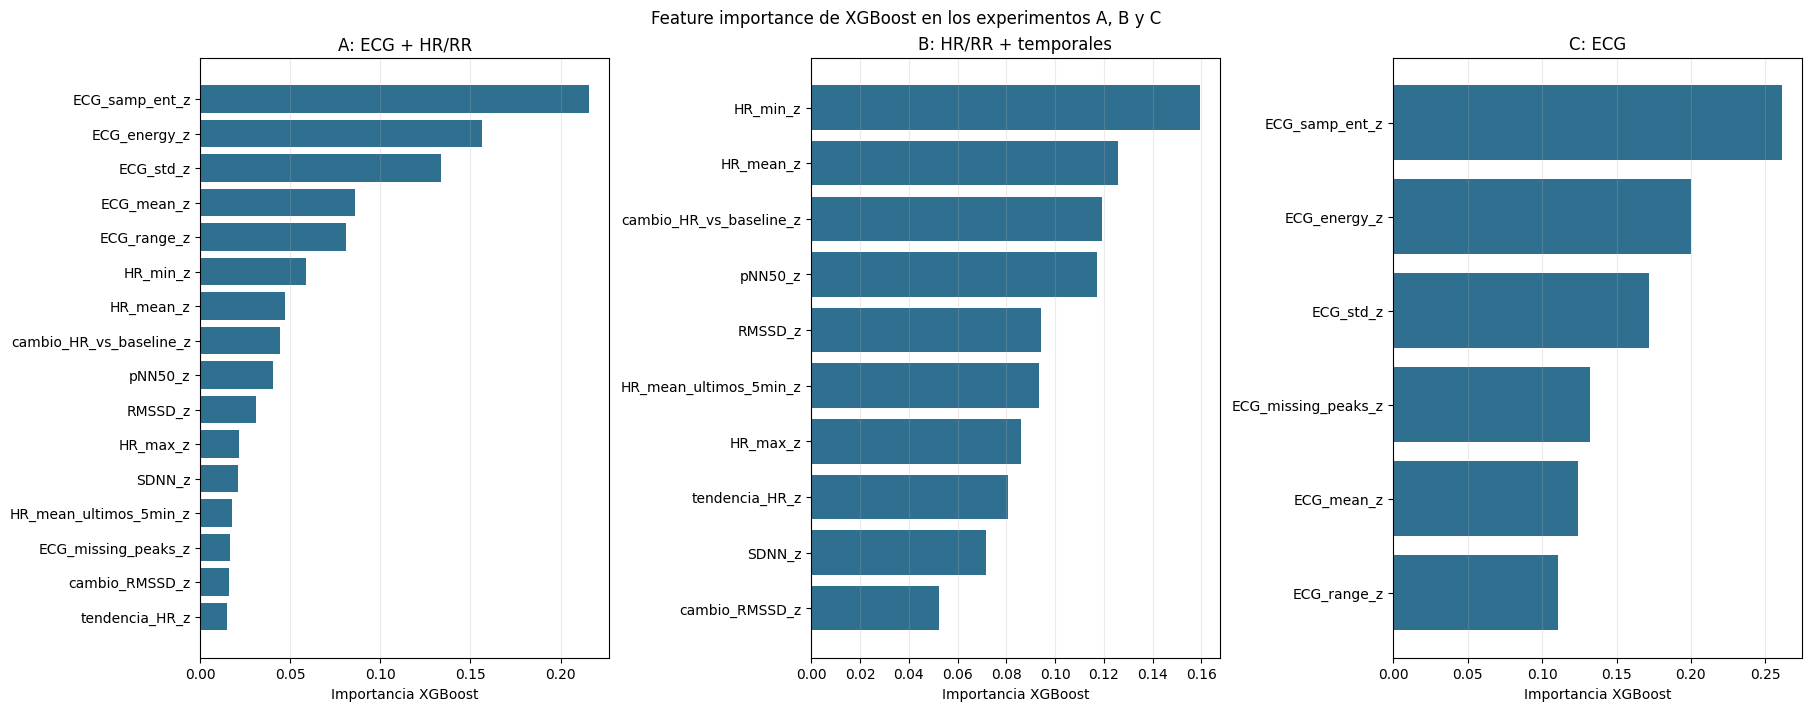

Features ordenadas por importancia:

A: ECG + HR/RR


,Feature,Importance
4,ECG_samp_ent_z,0.2160
0,ECG_energy_z,0.1566
5,ECG_std_z,0.1335
1,ECG_mean_z,0.0858
3,ECG_range_z,0.0810
8,HR_min_z,0.0588
7,HR_mean_z,0.0471
13,cambio_HR_vs_baseline_z,0.0442
11,pNN50_z,0.0402
9,RMSSD_z,0.0306



B: HR/RR + temporales


,Feature,Importance
5,HR_min_z,0.1595
3,HR_mean_z,0.1258
7,cambio_HR_vs_baseline_z,0.1191
2,pNN50_z,0.1170
1,RMSSD_z,0.0940
6,HR_mean_ultimos_5min_z,0.0936
4,HR_max_z,0.0862
8,tendencia_HR_z,0.0807
0,SDNN_z,0.0718
9,cambio_RMSSD_z,0.0522



C: ECG


,Feature,Importance
4,ECG_samp_ent_z,0.2614
0,ECG_energy_z,0.2002
5,ECG_std_z,0.1718
2,ECG_missing_peaks_z,0.1319
1,ECG_mean_z,0.1243
3,ECG_range_z,0.1104


In [9]:
import matplotlib.pyplot as plt


def fit_final_feature_model(selected_features):
    X_selected = all_frame.loc[all_mask, selected_features]
    return optimize_model(X_selected, y_all).best_estimator_


models_by_experiment = {
    'A: ECG + HR/RR': (feature_columns, fit_final_feature_model(feature_columns)),
    'B: HR/RR + temporales': (HR_RR_FEATURES, fit_final_feature_model(HR_RR_FEATURES)),
    'C: ECG': (ECG_FEATURES, fit_final_feature_model(ECG_FEATURES)),
}

importance_tables = {}
for experiment_name, (selected_features, model) in models_by_experiment.items():
    importance = model.named_steps['classifier'].feature_importances_
    importance_tables[experiment_name] = (
        pd.DataFrame({'Feature': selected_features, 'Importance': importance})
        .sort_values('Importance', ascending=True)
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
for axis, (experiment_name, importance_table) in zip(axes, importance_tables.items()):
    axis.barh(importance_table['Feature'], importance_table['Importance'], color='#2f6f8f')
    axis.set_title(experiment_name)
    axis.set_xlabel('Importancia XGBoost')
    axis.grid(axis='x', alpha=0.25)

fig.suptitle('Feature importance de XGBoost en los experimentos A, B y C')
plt.show()

print('Features ordenadas por importancia:')
for experiment_name, importance_table in importance_tables.items():
    print(f'\n{experiment_name}')
    display(importance_table.sort_values('Importance', ascending=False).round(4))